In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from kret_sandbox.VIS import dtt

In [4]:
config = EnvConfig(max_new_requests_per_step=2)

In [5]:
"""
Define the observation space for the environment.
    - globals: day of week (sin, cos), time of day (sin, cos), weather_one_hot(3) (7,) #TODO stretch goal: add demand per node, next step speed limits
    - supply_demand_ratio: current supply-demand ratio, vehicle-per-node, lambda-per-node (3,)
    - vehicles: (num_vehicles, 7) -> [loc_x_norm, loc_y_norm, battery, status_one_hot(4)]
    - pending_requests: (max_pending_requests, 9) -> [pickup_x_norm, pickup_y_norm, dropoff_x_norm, dropoff_y_norm, distance_meters, est_cost, max_wait_time, wait_time, status_one_hot(1)] # TODO add max wait time before
    - active_rides: (num_vehicles, 8) -> [pickup_x_norm, pickup_y_norm, dropoff_x_norm, dropoff_y_norm, price, total_trip_distance, trip_distance_remaining, pickup_distance_remaining]
    - dispatch_mask: (num_vehicles) -> 1 if vehicle can be dispatched to request, else 0
    - pricing_mask: (max_pending_requests) -> 1 if request needs pricing decision, else 0
"""

""

''

In [6]:
# config = ActiveRideDF.space_config(config, 10)
# config["shape"]

In [7]:
env = RideShareEnv(config=config)
G = env.G
cfg = env.config

0


/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/coding/Columbia/RL-Project/waymo_agent/graph_env/mixin/obs_space_mixin.py:81: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  requests = RequestDF(pd.concat([real_requests, filler_requests], ignore_index=True).reset_index(drop=True))
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gy

In [8]:
s, info = env.reset()

0


/Users/Akseldkw/coding/Columbia/RL-Project/waymo_agent/graph_env/mixin/obs_space_mixin.py:81: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  requests = RequestDF(pd.concat([real_requests, filler_requests], ignore_index=True).reset_index(drop=True))
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


In [9]:
veh = env.observation_curr["vehicles"]
req = env.observation_curr["pending_requests"]
rides = env.observation_curr["active_rides"]
type(veh), type(req), type(rides)

(waymo_agent.data_classes.vehicles.VehicleDF,
 waymo_agent.data_classes.requests.RequestDF,
 waymo_agent.data_classes.active_rides.ActiveRideDF)

In [10]:
req.head()

,request_id,request_dt,pickup_node_id,pickup_x_norm,pickup_y_norm,cust_id,cust_bias,cust_temperature,dropoff_node_id,dropoff_x_norm,...,route_nodes,curr_start_node,curr_end_node,route_dist_on_edge,distance_meters,est_cost,price,max_wait_time,wait_time,status
0,-1,2025-01-01,-1,-1.0,-1.0,-1,-1.0,-1.0,-1,-1.0,...,[],-1,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,0 days,-1
1,-1,2025-01-01,-1,-1.0,-1.0,-1,-1.0,-1.0,-1,-1.0,...,[],-1,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,0 days,-1
2,-1,2025-01-01,-1,-1.0,-1.0,-1,-1.0,-1.0,-1,-1.0,...,[],-1,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,0 days,-1
3,-1,2025-01-01,-1,-1.0,-1.0,-1,-1.0,-1.0,-1,-1.0,...,[],-1,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,0 days,-1
4,-1,2025-01-01,-1,-1.0,-1.0,-1,-1.0,-1.0,-1,-1.0,...,[],-1,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,0 days,-1


In [11]:
veh.shape, req.shape, rides.shape

((2, 6), (25, 21), (2, 18))

In [12]:
cfg = env.config
cfg.lambda_per_node * env.num_nodes
cfg.max_new_requests_per_step

2

In [13]:
action = env.action_space.sample()
dispatches = pd.DataFrame({"dispatch": action["dispatch"]})
prices = pd.DataFrame({"prices": action["prices"]})
reposition = pd.DataFrame(action["reposition"], columns=["x", "y"])

In [14]:
# reposition.hist(bins="rice")

In [15]:
# prices.hist(bins="rice")

In [16]:
# dispatches.hist(bins="rice")

Rendered step 0 with 0 active rides, 0 pending requests, and 2 vehicles.


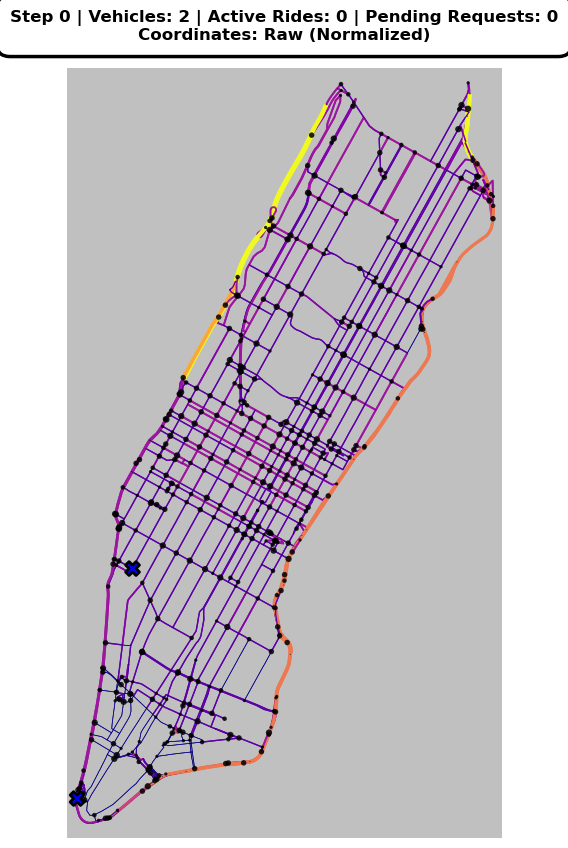

In [18]:
fig, ax = env.render()
# fig